In [101]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data load in

In [10]:
# Ignore future warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [16]:
def get_binance_bars(symbol, interval, startTime, endTime):
    url = "https://api.binance.com/api/v3/klines"
    startTime = str(int(startTime.timestamp() * 1000))
    endTime = str(int(endTime.timestamp() * 1000))
    limit = '1000'
    req_params = {"symbol": symbol, 'interval': interval, 'startTime': startTime, 'endTime': endTime, 'limit': limit}
    
    df = pd.DataFrame(json.loads(requests.get(url, params=req_params).text))
    if (len(df.index) == 0):
        return None
    df = df.iloc[:, 0:6]
    df.columns = ['datetime', 'open', 'high', 'low', 'close', 'volume']
    df.open = df.open.astype("float")
    df.high = df.high.astype("float")
    df.low = df.low.astype("float")
    df.close = df.close.astype("float")
    df.volume = df.volume.astype("float")
    df['adj_close'] = df['close']
    df.index = [dt.datetime.fromtimestamp(x / 1000.0) for x in df.datetime]
    return df

# Get Bitcoin daily data
symbol = 'BTCUSDT'  # Bitcoin 
interval = '1d'     # Daily interval

df_list = []
last_datetime = dt.datetime(2018, 1, 1)

while True:
    print(last_datetime)
    new_df = get_binance_bars(symbol, interval, last_datetime, dt.datetime.now())
    if new_df is None:
        break
    df_list.append(new_df)
    last_datetime = max(new_df.index) + dt.timedelta(0, 1)
    time.sleep(0.5)  # Small delay to be nice to the API

df = pd.concat(df_list)
df = df.drop(columns=["datetime", "adj_close"])
df.columns = ["Open", "High", "Low", "Close", "Volume"]
df.to_csv('BTCUSDT_daily.csv', index_label="Date")

2018-01-01 00:00:00
2020-09-26 10:00:01
2023-06-23 10:00:01
2026-03-19 11:00:01
2026-04-27 10:00:01


In [18]:
df = pd.read_csv('BTCUSDT_daily.csv')
df

,Date,Open,High,Low,Close,Volume
0,2018-01-01 11:00:00,13715.65,13818.55,12750.00,13380.00,8609.915844
1,2018-01-02 11:00:00,13382.16,15473.49,12890.02,14675.11,20078.092111
2,2018-01-03 11:00:00,14690.00,15307.56,14150.00,14919.51,15905.667639
3,2018-01-04 11:00:00,14919.51,15280.00,13918.04,15059.54,21329.649574
4,2018-01-05 11:00:00,15059.56,17176.24,14600.00,16960.39,23251.491125
...,...,...,...,...,...,...
3034,2026-04-23 10:00:00,78178.22,78662.50,76960.00,78257.48,16970.795010
3035,2026-04-24 10:00:00,78257.48,78581.93,77264.08,77437.13,12675.143150
3036,2026-04-25 10:00:00,77437.13,77885.35,77140.23,77625.00,5685.114200
3037,2026-04-26 10:00:00,77625.00,78961.00,77326.51,78657.55,7963.561620


In [20]:
df = pd.read_csv('BTCUSDT_daily.csv', index_col='Date', parse_dates=True)

df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

df = df.dropna()

df.to_csv('BTCUSDT_daily_with_returns.csv', index_label='Date')

df.head()

,Open,High,Low,Close,Volume,log_return
Date,,,,,,
2018-01-02 11:00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,0.092392
2018-01-03 11:00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,0.016517
2018-01-04 11:00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,0.009342
2018-01-05 11:00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,0.118869
2018-01-06 11:00:00,16960.39,17143.13,16011.21,17069.79,18571.457508,0.006430


Bitcoin with log return is saved in BTCUSDT_daily_with_returns.csv, then I load in ETH, calculate return then combine with this dataset

In [22]:
def get_binance_bars(symbol, interval, startTime, endTime):
    url = "https://api.binance.com/api/v3/klines"
    startTime = str(int(startTime.timestamp() * 1000))
    endTime = str(int(endTime.timestamp() * 1000))
    limit = '1000'
    req_params = {"symbol": symbol, 'interval': interval, 'startTime': startTime, 'endTime': endTime, 'limit': limit}
    
    df = pd.DataFrame(json.loads(requests.get(url, params=req_params).text))
    if (len(df.index) == 0):
        return None
    df = df.iloc[:, 0:6]
    df.columns = ['datetime', 'open', 'high', 'low', 'close', 'volume']
    df.open = df.open.astype("float")
    df.high = df.high.astype("float")
    df.low = df.low.astype("float")
    df.close = df.close.astype("float")
    df.volume = df.volume.astype("float")
    df['adj_close'] = df['close']
    df.index = [dt.datetime.fromtimestamp(x / 1000.0) for x in df.datetime]
    return df

# Get ETH daily data
symbol_eth = 'ETHUSDT'
interval = '1d'
df_list_eth = []
last_datetime_eth = dt.datetime(2018, 1, 1)

while True:
    print(last_datetime_eth)
    new_df_eth = get_binance_bars(symbol_eth, interval, last_datetime_eth, dt.datetime.now())
    if new_df_eth is None:
        break
    df_list_eth.append(new_df_eth)
    last_datetime_eth = max(new_df_eth.index) + dt.timedelta(0, 1)
    time.sleep(0.5)

df_eth = pd.concat(df_list_eth)
df_eth = df_eth.drop(columns=["datetime", "adj_close"])
df_eth.columns = ["Open", "High", "Low", "Close", "Volume"]
df_eth.to_csv('ETHUSDT_daily.csv', index_label="Date")

2018-01-01 00:00:00
2020-09-26 10:00:01
2023-06-23 10:00:01
2026-03-19 11:00:01
2026-04-27 10:00:01


In [34]:
# Load both CSVs
df_btc = pd.read_csv('BTCUSDT_daily_with_returns.csv', index_col='Date', parse_dates=True)
df_eth = pd.read_csv('ETHUSDT_daily.csv', index_col='Date', parse_dates=True)

# Calculate ETH log returns
df_eth['ETH_LogReturns'] = np.log(df_eth['Close'] / df_eth['Close'].shift(1))

# Merge on date index
df_combined = df_btc.copy()
df_combined['ETH_LogReturns'] = df_eth['ETH_LogReturns']

# Drop any rows where ETH data is missing
df_combined = df_combined.dropna()
df_combined.to_csv('BTCUSDT_with_ETH.csv', index_label='Date')

In [36]:
df = pd.read_csv('BTCUSDT_with_ETH.csv', index_col='Date', parse_dates=True)
df

,Open,High,Low,Close,Volume,log_return,ETH_LogReturns
Date,,,,,,,
2018-01-02 11:00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,0.092392,0.124724
2018-01-03 11:00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,0.016517,0.088080
2018-01-04 11:00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,0.009342,0.006371
2018-01-05 11:00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,0.118869,0.020324
2018-01-06 11:00:00,16960.39,17143.13,16011.21,17069.79,18571.457508,0.006430,0.045653
...,...,...,...,...,...,...,...
2026-04-23 10:00:00,78178.22,78662.50,76960.00,78257.48,16970.795010,0.001013,-0.018626
2026-04-24 10:00:00,78257.48,78581.93,77264.08,77437.13,12675.143150,-0.010538,-0.006574
2026-04-25 10:00:00,77437.13,77885.35,77140.23,77625.00,5685.114200,0.002423,0.001946


Right now the data is called BTCUSDT_with_ETH

In [56]:
df = pd.read_csv('BTCUSDT_with_ETH.csv', index_col='Date', parse_dates=True)

# 1. Parkinson Volatility
df['Volatility'] = (np.log(df['High']) - np.log(df['Low'])) ** 2 / (4 * np.log(2))

# 2. RSI_14
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 3. ATR_14
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(window=14).mean()

# Drop OHLCV columns, keep only what we need
df = df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'])

# Drop NaNs
df = df.dropna()

print(df[['log_return', 'ETH_LogReturns', 'Volatility', 'RSI_14', 'ATR_14']].head())
print(df.shape)

                     log_return  ETH_LogReturns  Volatility     RSI_14  \
Date                                                                     
2018-01-16 11:00:00   -0.216880       -0.239804    0.059089  33.799160   
2018-01-17 11:00:00    0.008113        0.000000    0.023735  32.903015   
2018-01-18 11:00:00   -0.002444       -0.006018    0.006054  32.000018   
2018-01-19 11:00:00    0.045737        0.038001    0.006069  22.557335   
2018-01-20 11:00:00    0.109271        0.110167    0.006852  30.954953   

                          ATR_14  
Date                              
2018-01-16 11:00:00  1998.141429  
2018-01-17 11:00:00  2104.247857  
2018-01-18 11:00:00  2110.071429  
2018-01-19 11:00:00  2028.554286  
2018-01-20 11:00:00  2068.170714  
(3024, 5)


In [58]:
df.to_csv('BTCUSDT_features.csv', index_label='Date')
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14
Date,,,,,
2018-01-16 11:00:00,-0.216880,-0.239804,0.059089,33.799160,1998.141429
2018-01-17 11:00:00,0.008113,0.000000,0.023735,32.903015,2104.247857
2018-01-18 11:00:00,-0.002444,-0.006018,0.006054,32.000018,2110.071429
2018-01-19 11:00:00,0.045737,0.038001,0.006069,22.557335,2028.554286
2018-01-20 11:00:00,0.109271,0.110167,0.006852,30.954953,2068.170714
...,...,...,...,...,...
2026-04-23 10:00:00,0.001013,-0.018626,0.000173,67.785917,2490.466429
2026-04-24 10:00:00,-0.010538,-0.006574,0.000103,62.545513,2441.180714
2026-04-25 10:00:00,0.002423,0.001946,0.000033,62.769757,2403.195714


Now add in 3 more internal features

## Combining external features of block chain

In [70]:

blockchain_files = [
    'blocksize_2018_2026.csv',
    'cost-per-transaction_2018_2026.csv',
    'difficulty_2018_2026.csv',
    'hash-rate_2018_2026.csv',
    'n-payments-per-block_2018_2026.csv',
    'n-transactions-per-block_2018_2026.csv',
    'n-transactions-total_2018_2026.csv',
    'avgblocksize_2018_2026.csv',
]


df = pd.read_csv('BTCUSDT_features.csv', index_col='Date', parse_dates=True)


for file in blockchain_files:

    feature_name = file.replace('_2018_2026.csv', '').replace('-', '_')
    

    df_block = pd.read_csv(file)

    df_block.columns = ['timestamp', feature_name, 'date']
    
    df_block['date'] = pd.to_datetime(df_block['date'])
    df_block = df_block.set_index('date')

    df_block = df_block[[feature_name]]
    
    df.index = df.index.normalize()  
    
    df = df.join(df_block, how='left')
    df = df[df.index < '2026-04-27']


df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,-0.239804,0.059089,33.799160,1998.141429,152685.278912,103.199991,2.227848e+12,1.760876e+07,3866.968553,1910.220126,2.927858e+08,1.050054
2018-01-17,0.008113,0.000000,0.023735,32.903015,2104.247857,152852.219190,92.776244,2.227848e+12,1.849473e+07,3790.443114,1890.844311,2.930894e+08,1.062211
2018-01-18,-0.002444,-0.006018,0.006054,32.000018,2110.071429,153029.607111,104.663623,2.227848e+12,1.915921e+07,3614.161850,1788.988439,2.934048e+08,1.050849
2018-01-19,0.045737,0.038001,0.006069,22.557335,2028.554286,153211.414962,120.900343,2.227848e+12,1.827324e+07,2937.781818,1476.478788,2.937147e+08,1.048357
2018-01-20,0.109271,0.110167,0.006852,30.954953,2068.170714,153384.377157,137.559285,2.227848e+12,1.971295e+07,2682.123596,1351.747191,2.939573e+08,1.106569
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.019966,0.000665,68.878984,2560.216429,735335.099355,59.640498,1.355949e+14,8.830000e+08,6364.030534,4143.870229,1.343837e+09,1.585138
2026-04-23,0.001013,-0.018626,0.000173,67.785917,2490.466429,735542.898417,65.972572,1.355949e+14,8.155954e+08,6094.545455,3725.826446,1.344377e+09,1.549204
2026-04-24,-0.010538,-0.006574,0.000103,62.545513,2441.180714,735730.223121,62.505066,1.355949e+14,1.004328e+09,6225.342282,3957.026846,1.344828e+09,1.568398


Then normalise all features

In [108]:
# All features to normalise (inputs only, NOT LogReturns)
feature_cols = [
    'Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
    'blocksize', 'cost_per_transaction', 'difficulty',
    'hash_rate', 'n_payments_per_block', 
    'n_transactions_per_block', 'n_transactions_total',
    'avgblocksize'
]

# Fill NaN before scaling
df = df.fillna(method='ffill').fillna(method='bfill')

# Fit scaler on training data only to avoid leakage
train_size = int(len(df) * 0.70)
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = df.copy()

# Fit on train only, transform all
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# Verify no NaN remaining
print(f"NaN remaining: {df_scaled[feature_cols].isna().sum().sum()}")
print(df_scaled.shape)
df_scaled

NaN remaining: 0
(3023, 13)


,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [110]:
df_scaled.to_csv('BTCUSDT_full_features.csv', index_label='Date')
df_scaled

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


This is finally saved int new csv file BTCUSDT_full_features

## Visual exploration

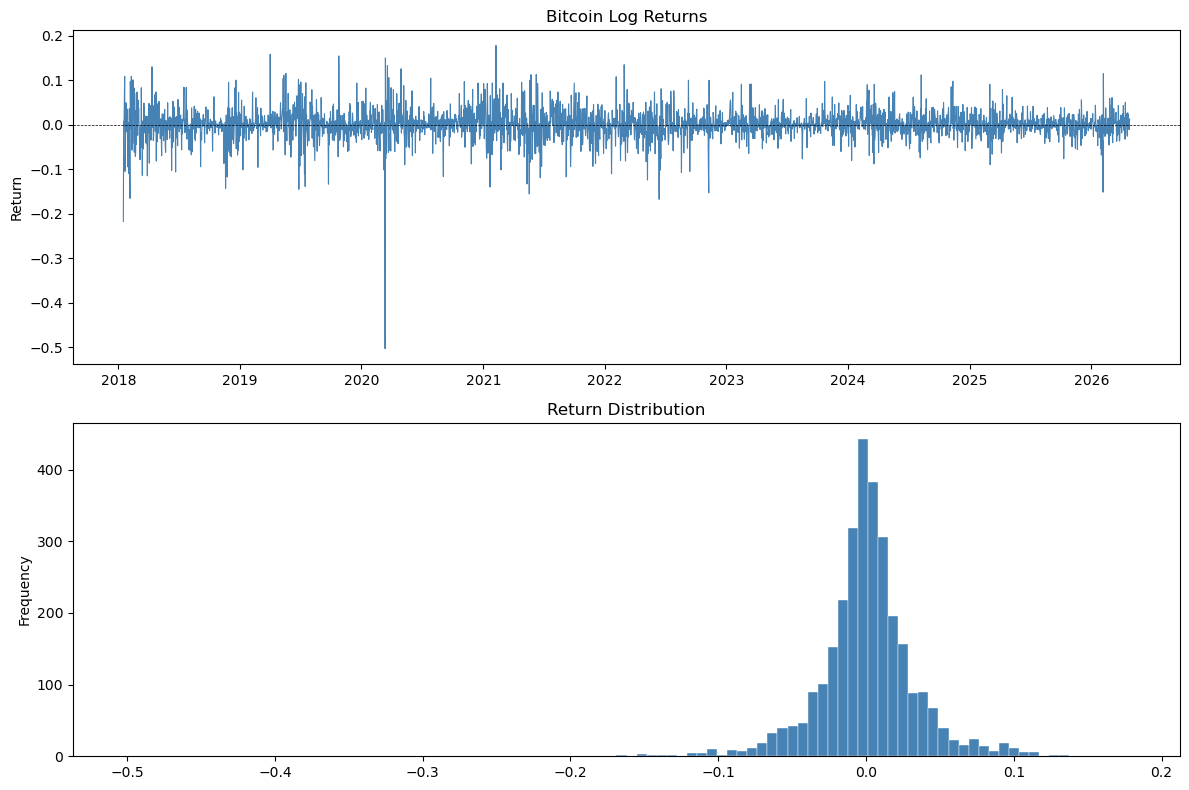

In [112]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df_scaled.index, df_scaled['log_return'], color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('Bitcoin Log Returns')
axes[0].set_ylabel('Return')

axes[1].hist(df_scaled['log_return'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Return Distribution')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('btc_overview.png', dpi=150)
plt.show()

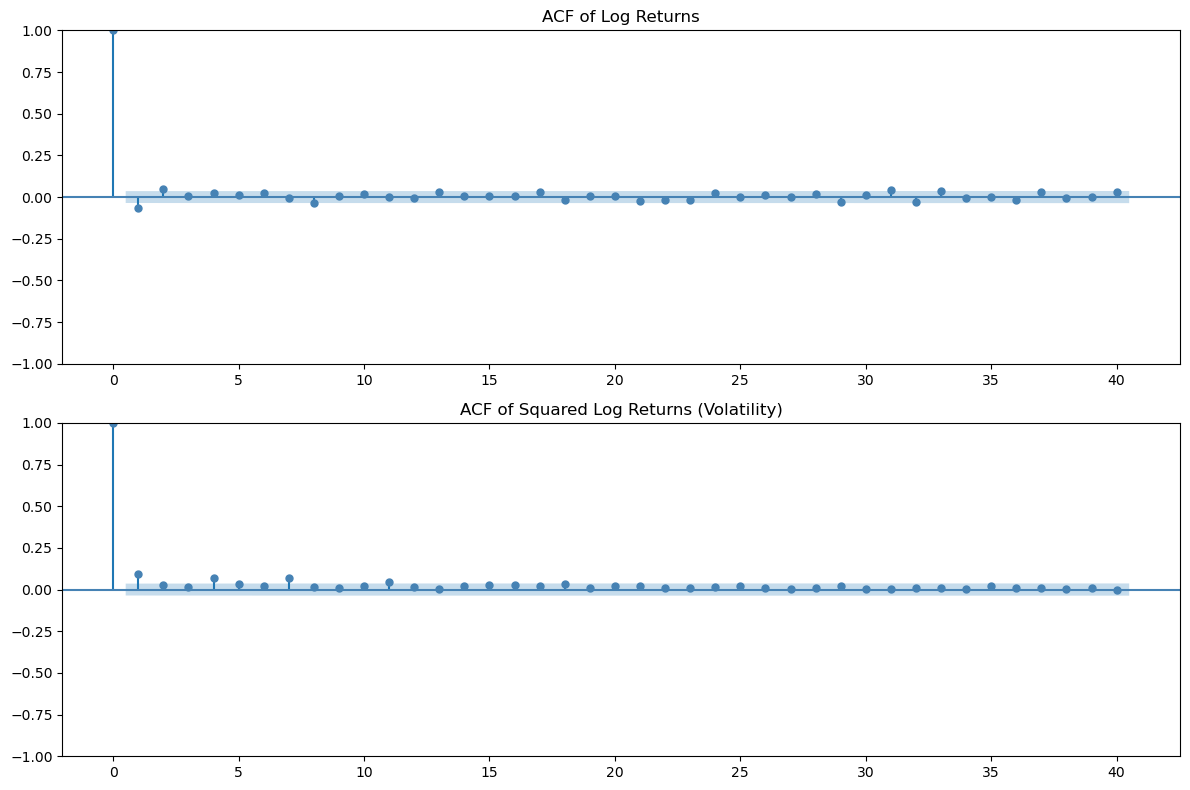

In [114]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['log_return'], lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF of Log Returns')

plot_acf(df['log_return']**2, lags=40, ax=axes[1], color='steelblue')
axes[1].set_title('ACF of Squared Log Returns (Volatility)')

plt.tight_layout()
plt.savefig('btc_acf.png', dpi=150)
plt.show()

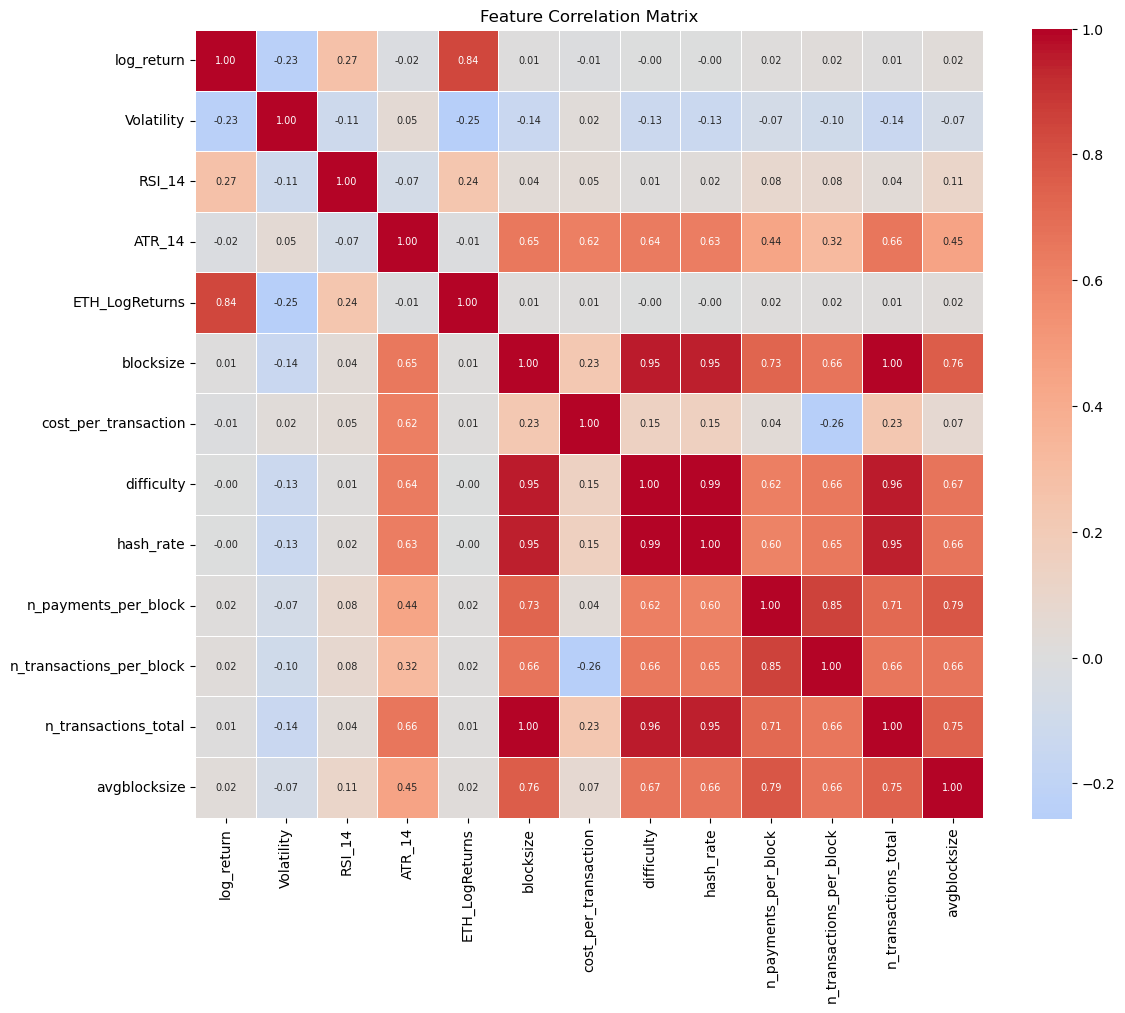

In [116]:
corr = df_scaled[['log_return', 'Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                   'blocksize', 'cost_per_transaction', 'difficulty',
                   'hash_rate', 'n_payments_per_block',
                   'n_transactions_per_block', 'n_transactions_total',
                   'avgblocksize']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

## Summary table for dataset and features

In [121]:
print(df_scaled.columns.tolist())

['log_return', 'ETH_LogReturns', 'Volatility', 'RSI_14', 'ATR_14', 'blocksize', 'cost_per_transaction', 'difficulty', 'hash_rate', 'n_payments_per_block', 'n_transactions_per_block', 'n_transactions_total', 'avgblocksize']


In [125]:
def hurst_exponent(ts):
    ts = np.array(ts)
    lags = range(2, 20)
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

df_scaled = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)

train_size = int(len(df_scaled) * 0.70)
val_size = int(len(df_scaled) * 0.15)

split_slices = {
    'Training':   slice(0, train_size),
    'Validation': slice(train_size, train_size + val_size),
    'Test':       slice(train_size + val_size, None)
}

var_names = {
    'log_return':               'Log Return',
    'ETH_LogReturns':           'ETH Log Return',
    'Volatility':               'Volatility',
    'RSI_14':                   'RSI (14)',
    'ATR_14':                   'ATR (14)',
    'blocksize':                'Block Size',
    'cost_per_transaction':     'Cost per Transaction',
    'difficulty':               'Difficulty',
    'hash_rate':                'Hash Rate',
    'n_payments_per_block':     'Payments per Block',
    'n_transactions_per_block': 'Transactions per Block',
    'n_transactions_total':     'Total Transactions',
    'avgblocksize':             'Avg Block Size',
}

rows = []
for col, name in var_names.items():
    for split_name, slc in split_slices.items():
        series = df_scaled[col].iloc[slc].dropna()
        rows.append({
            'Variable': name,
            'Split': split_name,
            'Mean': round(series.mean(), 4),
            'SD': round(series.std(), 4),
            'Median': round(series.median(), 4),
            'Skew.': round(series.skew(), 2),
            'Kurt.': round(series.kurt(), 2),
            'Hurst': round(hurst_exponent(series.values), 3),
        })

summary_df = pd.DataFrame(rows)
summary_df

,Variable,Split,Mean,SD,Median,Skew.,Kurt.,Hurst
0,Log Return,Training,0.0005,0.0377,0.0003,-1.27,17.46,0.005
1,Log Return,Validation,0.0023,0.0267,0.0015,0.27,1.73,0.005
2,Log Return,Test,-0.0006,0.0238,-0.0002,-0.27,5.50,-0.006
3,ETH Log Return,Training,0.7166,0.0592,0.7170,-1.16,13.19,0.007
4,ETH Log Return,Validation,0.7179,0.0399,0.7180,0.48,3.12,0.003
5,ETH Log Return,Test,0.7156,0.0475,0.7163,0.13,3.39,-0.007
6,Volatility,Training,0.0125,0.0339,0.0052,16.69,406.69,0.031
7,Volatility,Validation,0.0063,0.0086,0.0036,4.37,27.91,0.030
8,Volatility,Test,0.0049,0.0087,0.0026,6.61,57.99,0.061
9,RSI (14),Training,0.4929,0.1925,0.4874,0.10,-0.44,0.436
